# SAJU ML Expansion Validation V2

## Purpose

This notebook is the **external new-subject validation stage** after V1.4.

V1.4 already selected two candidate feature families on `SAJU_ML_CORPUS_V1`:

- `TENGOD` — 10 features
- `SHINSAL_ALL` — 43 features

The model family is frozen:

> Pairwise Logistic Regression, StandardScaler, L2, `C=0.3`

This notebook must **not** reopen broad feature search.

## Two-stage protocol

```text
V1 discovery data
    ↓ fit frozen candidate A/B
NEW_DEV 70 completely new subjects
    ↓ external evaluation only
predeclared gate + choose at most one winner
    ↓ write V2_DEV_WINNER_FREEZE.json
optional refit same winner on V1 + NEW_DEV
    ↓
NEW_CONFIRM 30 fresh subjects
    ↓ one-shot, only after manual RUN_CONFIRM=True
final report
```

`NEW_CONFIRM` is not loaded at all while `RUN_CONFIRM=False`.

**R2 engine-range fix:** the corpus and notebook now enforce the runtime `sajupy` birth-year range before any feature extraction. The R1 corpus contained two pre-1900 NEW_DEV subjects; they were replaced before any V2 model score was produced.

## Hard boundaries

- Validation B: permanently forbidden
- Public Life CHECK: forbidden
- Public Life FINAL: forbidden
- No new feature family
- No TENGOD + SHINSAL composite
- No hyperparameter search
- No coefficient sign editing
- Names are audit-only, never features
- Do not change V2 labels after seeing model scores

In [7]:
from pathlib import Path
from itertools import product
from collections import Counter
from datetime import datetime
import hashlib
import json
import re
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

SEED = 20260815
TARGET_DOMAIN = "Career"
N_BOOTSTRAP = 20000

# IMPORTANT:
# First run with False. Review NEW_DEV result + freeze before changing to True.
RUN_CONFIRM = False

def find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / "saju_engine.py").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find repo root containing saju_engine.py. "
        "Run this notebook from inside the Chartpalja saju repo."
    )

REPO_ROOT = find_repo_root()

V1_CORPUS_DIR = REPO_ROOT / "research" / "ml_corpus" / "v1"
V2_CORPUS_DIR = REPO_ROOT / "research" / "ml_corpus" / "v2"

V1_ARTIFACT_DIR = REPO_ROOT / "research" / "ml" / "artifacts" / "v1"
V13_ARTIFACT_DIR = REPO_ROOT / "research" / "ml" / "artifacts" / "v1_3"
V2_ARTIFACT_DIR = REPO_ROOT / "research" / "ml" / "artifacts" / "v2"
V2_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

V1_CORPUS_PATH = V1_CORPUS_DIR / "SAJU_ML_CORPUS_V1.json"
V2_DEV_PATH = V2_CORPUS_DIR / "SAJU_ML_CORPUS_V2_NEW_DEV.json"
V2_CONFIRM_PATH = V2_CORPUS_DIR / "SAJU_ML_CORPUS_V2_NEW_CONFIRM_SEALED.json"
V2_ENGINE_INPUTS_PATH = V2_CORPUS_DIR / "SAJU_ML_ENGINE_INPUTS_V2.json"
CANDIDATE_FREEZE_PATH = V2_CORPUS_DIR / "SAJU_ML_V2_CANDIDATE_FREEZE.json"

WINNER_FREEZE_PATH = V2_ARTIFACT_DIR / "V2_DEV_WINNER_FREEZE.json"

print("repo:", REPO_ROOT)
print("RUN_CONFIRM:", RUN_CONFIRM)
print("V2 artifacts:", V2_ARTIFACT_DIR)

repo: /Users/sangjinlee/Desktop/projects/saju
RUN_CONFIRM: False
V2 artifacts: /Users/sangjinlee/Desktop/projects/saju/research/ml/artifacts/v2


## 1. Integrity helpers

In [8]:
def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

def load_json(path):
    return json.load(open(path, encoding="utf-8"))

required = [
    V1_CORPUS_PATH,
    V2_DEV_PATH,
    V2_ENGINE_INPUTS_PATH,
    CANDIDATE_FREEZE_PATH,
]
for p in required:
    if not p.exists():
        raise FileNotFoundError(p)

v1_corpus = load_json(V1_CORPUS_PATH)
v2_dev_corpus = load_json(V2_DEV_PATH)
engine_inputs_v2 = load_json(V2_ENGINE_INPUTS_PATH)
candidate_freeze = load_json(CANDIDATE_FREEZE_PATH)

assert v1_corpus["corpus_version"] == "SAJU_ML_CORPUS_V1"
assert v2_dev_corpus["corpus_version"] == "SAJU_ML_CORPUS_V2_NEW_DEV"
assert set(candidate_freeze["candidates"]) == {"TENGOD", "SHINSAL_ALL"}
assert float(candidate_freeze["model"]["C"]) == 0.3

v1_names = {s["name"] for s in v1_corpus["subjects"]}
v2_dev_names = {s["name"] for s in v2_dev_corpus["subjects"]}
assert not (v1_names & v2_dev_names), "V1/V2 subject overlap"

assert len(v2_dev_corpus["subjects"]) == 70
assert all(s["source_pool"] == "NEW_DEV" for s in v2_dev_corpus["subjects"])
assert all(s["birth"]["birth_time_known"] for s in v2_dev_corpus["subjects"])


def birth_year(subject):
    return int(str(subject["birth"]["date"])[:4])

unsupported_static = [
    (s["subject_id"], s["name"], birth_year(s))
    for s in v2_dev_corpus["subjects"]
    if not (1900 <= birth_year(s) <= 2100)
]
if unsupported_static:
    raise RuntimeError(
        "V2 corpus contains births outside the supported engine range 1900–2100: "
        f"{unsupported_static}"
    )

print("V1 subjects:", len(v1_corpus["subjects"]))
print("V2 NEW_DEV subjects:", len(v2_dev_corpus["subjects"]))
print("V1/V2 overlap:", len(v1_names & v2_dev_names))
print("Static engine-year preflight: PASS (1900–2100)")

V1 subjects: 94
V2 NEW_DEV subjects: 70
V1/V2 overlap: 0
Static engine-year preflight: PASS (1900–2100)


## 2. Career labels

Rules are identical across V1 and V2:

- unknown is excluded
- same-subject same-year positive/negative conflicts are excluded
- subject must contain both signs to be pair-evaluable
- source confidence `low` is never usable

In [9]:
def build_target_rows(corpus, domain="Career", high_only=False):
    raw = []

    for s in corpus["subjects"]:
        for e in s["events"]:
            if not e.get("ml_usable", False):
                continue
            if high_only and str(e.get("source_event_confidence", "")).lower() != "high":
                continue

            lab = e["targets"].get(domain, "unknown")
            if lab not in {"positive", "negative"}:
                continue

            raw.append({
                "subject_id": s["subject_id"],
                "name": s["name"],
                "source_pool": s["source_pool"],
                "origin_group": s.get("origin_group"),
                "year": int(e["year"]),
                "label": 1 if lab == "positive" else 0,
                "source_event_confidence": e.get("source_event_confidence"),
            })

    raw_df = pd.DataFrame(raw)
    rows = []
    collisions = []

    for (sid, year), g in raw_df.groupby(["subject_id", "year"]):
        if g["label"].nunique() > 1:
            collisions.append((sid, int(year)))
            continue

        rows.append({
            "subject_id": sid,
            "name": g["name"].iloc[0],
            "source_pool": g["source_pool"].iloc[0],
            "origin_group": g["origin_group"].iloc[0],
            "year": int(year),
            "label": int(g["label"].iloc[0]),
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df, collisions

    pairable = [
        sid for sid, g in df.groupby("subject_id")
        if set(g["label"]) == {0, 1}
    ]
    return df[df["subject_id"].isin(pairable)].copy(), collisions

v1_targets, v1_collisions = build_target_rows(v1_corpus)
dev_targets, dev_collisions = build_target_rows(v2_dev_corpus)
dev_targets_high, _ = build_target_rows(v2_dev_corpus, high_only=True)

print("V1 pair-evaluable subjects:", v1_targets["subject_id"].nunique())
print("V2 NEW_DEV pair-evaluable subjects:", dev_targets["subject_id"].nunique())
print("V2 NEW_DEV high-only pair-evaluable:", dev_targets_high["subject_id"].nunique())
print("V2 collisions:", dev_collisions)

assert dev_targets["subject_id"].nunique() == 70
assert len(dev_collisions) == 0

V1 pair-evaluable subjects: 34
V2 NEW_DEV pair-evaluable subjects: 70
V2 NEW_DEV high-only pair-evaluable: 17
V2 collisions: []


## 3. Load V1 frozen feature tables

V2 is an **external evaluation**, so candidate coefficients are first trained only from V1.

No V2 label is used to fit these first-stage models.

In [10]:
v1_feature_parquet = V1_ARTIFACT_DIR / "ml_feature_table_v1.parquet"
v1_feature_csv = V1_ARTIFACT_DIR / "ml_feature_table_v1.csv"
v13_extended_csv = V13_ARTIFACT_DIR / "extended_astrology_features_v1_3.csv"

if v1_feature_parquet.exists():
    v1_features = pd.read_parquet(v1_feature_parquet)
elif v1_feature_csv.exists():
    v1_features = pd.read_csv(v1_feature_csv)
else:
    raise FileNotFoundError(
        "Run saju_ml_research_v1.ipynb first: ml_feature_table_v1 missing."
    )

if not v13_extended_csv.exists():
    raise FileNotFoundError(
        "Run saju_ml_feature_sweep_v1_3.ipynb first: "
        "extended_astrology_features_v1_3.csv missing."
    )

v13_extended = pd.read_csv(v13_extended_csv)

v1_model_df = (
    v1_targets
    .merge(v1_features, on=["subject_id", "year"], how="inner", validate="one_to_one")
    .merge(v13_extended, on=["subject_id", "year"], how="left", validate="one_to_one")
    .fillna(0.0)
)

TENGOD_COLS = candidate_freeze["candidates"]["TENGOD"]["features"]
SHINSAL_COLS = candidate_freeze["candidates"]["SHINSAL_ALL"]["features"]

missing_tg = [c for c in TENGOD_COLS if c not in v1_model_df.columns]
missing_shin = [c for c in SHINSAL_COLS if c not in v1_model_df.columns]

if missing_tg:
    raise RuntimeError(f"V1 TENGOD schema drift: {missing_tg}")
if missing_shin:
    raise RuntimeError(f"V1 SHINSAL schema drift: {missing_shin}")

print("V1 model subjects:", v1_model_df["subject_id"].nunique())
print("TENGOD features:", len(TENGOD_COLS))
print("SHINSAL features:", len(SHINSAL_COLS))

V1 model subjects: 23
TENGOD features: 10
SHINSAL features: 43


## 4. V2 engine feature extraction

Use the same public-birth policy as V1 Public DEV:

1. civil local time
2. longitude solar correction
3. `BirthInput(... use_solar_time=False)`

Only the **already frozen** TENGOD and SHINSAL feature schemas are emitted.
Any new engine Shinsal column not present in the V1.4 freeze is ignored.

In [11]:
sys.path.insert(0, str(REPO_ROOT))
import saju_engine as se
import sajupy

STEMS = list("甲乙丙丁戊己庚辛壬癸")
BRANCHES = list("子丑寅卯辰巳午未申酉戌亥")

STEM_ELEMENT_EN = {
    "甲":"wood","乙":"wood","丙":"fire","丁":"fire","戊":"earth",
    "己":"earth","庚":"metal","辛":"metal","壬":"water","癸":"water"
}
GENERATES = {
    "wood":"fire","fire":"earth","earth":"metal","metal":"water","water":"wood"
}
CONTROLS = {
    "wood":"earth","earth":"water","water":"fire","fire":"metal","metal":"wood"
}

def parse_utc_offset(raw):
    if isinstance(raw, (int, float)):
        return float(raw)
    s = str(raw).strip()
    sign = -1.0 if s.startswith("-") else 1.0
    s = s[1:] if s[:1] in "+-" else s
    hh, mm = s.split(":")
    return sign * (int(hh) + int(mm) / 60.0)

def public_lon_corrected_birth(public_birth):
    y, m, d = map(int, public_birth["date"].split("-"))
    hh, mi = map(int, public_birth["time"].split(":")[:2])
    lon = float(public_birth["longitude"])
    utc_hours = parse_utc_offset(public_birth["utc_offset"])

    calc = sajupy.get_saju_calculator()
    civil = datetime(y, m, d, hh, mi)
    corr = float(calc._calculate_solar_time_correction(lon, utc_hours))
    h2, min2, dc = calc._adjust_time_for_solar(
        civil.hour, civil.minute, corr
    )
    y2, m2, d2 = calc._adjust_date_for_solar(
        civil.year, civil.month, civil.day, dc
    )

    return {
        "calendar": public_birth.get("calendar", "solar"),
        "y": y2, "m": m2, "d": d2,
        "h": h2, "min": min2,
    }

def pillar_chars(value):
    if isinstance(value, (list, tuple)) and len(value) >= 2:
        a, b = str(value[0]), str(value[1])
        if a in STEMS and b in BRANCHES:
            return a, b
    s = str(value)
    st = next((x for x in s if x in STEMS), None)
    br = next((x for x in s if x in BRANCHES), None)
    return st, br

def sexagenary_year_pillar(year):
    i = (int(year) - 1984) % 60
    return STEMS[i % 10] + BRANCHES[i % 12]

def ten_god_group(day_stem, other_stem):
    de = STEM_ELEMENT_EN[day_stem]
    oe = STEM_ELEMENT_EN[other_stem]
    if de == oe:
        return "peer"
    if GENERATES[de] == oe:
        return "output"
    if CONTROLS[de] == oe:
        return "wealth"
    if CONTROLS[oe] == de:
        return "officer"
    if GENERATES[oe] == de:
        return "resource"
    raise RuntimeError((day_stem, other_stem))

def get_daewoon_row(daewoon, year):
    for row in daewoon:
        if int(row["start_year"]) <= int(year) < int(row["end_year"]):
            return row
    return None

def get_sewoon_pillar(meta_row, year):
    for key in ("세운_pillar", "세운", "연주", "year_pillar"):
        if meta_row.get(key):
            st, br = pillar_chars(meta_row[key])
            if st and br:
                return st + br
    return sexagenary_year_pillar(year)

SHINSAL_KEYWORDS = ("신살", "귀인", "공망")

def safe_name(s):
    return re.sub(r"[^0-9A-Za-z가-힣_]+", "_", str(s))[:120]

def flatten_all(v, path, out):
    key = safe_name(path)
    if isinstance(v, bool):
        out[f"shinsal__{key}"] = float(v)
    elif isinstance(v, (int, float)) and np.isfinite(v):
        out[f"shinsal__{key}"] = float(v)
    elif isinstance(v, str):
        if v.strip():
            out[f"shinsal__{key}__{safe_name(v)}"] = 1.0
    elif isinstance(v, dict):
        for k2, v2 in v.items():
            flatten_all(v2, f"{path}.{k2}", out)
    elif isinstance(v, (list, tuple, set)):
        out[f"shinsal__{key}__count"] = float(len(v))
        for item in v:
            if isinstance(item, str):
                out[f"shinsal__{key}__{safe_name(item)}"] = 1.0
            elif isinstance(item, dict):
                flatten_all(item, path, out)

def flatten_selected(obj, prefix="", out=None):
    if out is None:
        out = {}

    if isinstance(obj, dict):
        for k, v in obj.items():
            path = f"{prefix}.{k}" if prefix else str(k)
            if any(token in path for token in SHINSAL_KEYWORDS):
                flatten_all(v, path, out)
            elif isinstance(v, (dict, list, tuple)):
                flatten_selected(v, path, out)

    elif isinstance(obj, (list, tuple)):
        for i, v in enumerate(obj):
            flatten_selected(v, f"{prefix}[{i}]", out)

    return out

def shinsal_features(dw_row, meta_row):
    out = {}

    if dw_row:
        bd = dw_row.get("breakdown") or {}
        if "shinsal" in bd:
            out["shinsal__dw_breakdown_scalar"] = float(
                bd.get("shinsal") or 0.0
            )

        gm = dw_row.get("gongmang_factors") or {}
        for k, v in gm.items():
            if isinstance(v, (int, float)):
                out[f"shinsal__dw_gongmang_{safe_name(k)}"] = float(v)

        ind = dw_row.get("indicators") or {}
        noble = ind.get("귀인력")
        if isinstance(noble, (int, float)):
            out["shinsal__dw_noble_power"] = float(noble)

        flatten_selected(dw_row, "dw", out)

    flatten_selected(meta_row, "sw", out)
    return out

def control_score_from_meta(meta_row):
    candle = meta_row.get("candle") or {}
    x = candle.get("close")
    return float(x) if x is not None else np.nan

engine_input_by_id = {
    x["subject_id"]: x
    for x in engine_inputs_v2["subjects"]
}


ENGINE_CALCULATOR = sajupy.get_saju_calculator()
ENGINE_MIN_YEAR = int(ENGINE_CALCULATOR.min_year)
ENGINE_MAX_YEAR = int(ENGINE_CALCULATOR.max_year)

def validate_runtime_birth_range(corpus, label):
    bad = []
    for s in corpus["subjects"]:
        rec = engine_input_by_id[s["subject_id"]]
        b = public_lon_corrected_birth(rec["public_birth"])
        y = int(b["y"])
        if not (ENGINE_MIN_YEAR <= y <= ENGINE_MAX_YEAR):
            bad.append({
                "subject_id": s["subject_id"],
                "name": s["name"],
                "corrected_year": y,
            })
    if bad:
        raise RuntimeError(
            f"{label}: longitude-corrected births outside sajupy "
            f"{ENGINE_MIN_YEAR}–{ENGINE_MAX_YEAR}: {bad}"
        )
    print(
        f"{label} runtime birth-range preflight: PASS "
        f"({ENGINE_MIN_YEAR}–{ENGINE_MAX_YEAR})"
    )

validate_runtime_birth_range(v2_dev_corpus, "NEW_DEV")

def compute_subject_engine(subject):
    rec = engine_input_by_id[subject["subject_id"]]
    assert rec["mode"] == "public_runtime_longitude_correction"

    b = public_lon_corrected_birth(rec["public_birth"])

    if not (ENGINE_MIN_YEAR <= int(b["y"]) <= ENGINE_MAX_YEAR):
        raise ValueError(
            f"Unsupported corrected birth year for {subject['subject_id']} "
            f"{subject['name']}: {b['y']} not in "
            f"{ENGINE_MIN_YEAR}–{ENGINE_MAX_YEAR}"
        )

    inp = se.BirthInput(
        year=int(b["y"]),
        month=int(b["m"]),
        day=int(b["d"]),
        hour=int(b["h"]),
        minute=int(b["min"]),
        gender=subject["gender"],
        calendar=b.get("calendar", "solar"),
        is_leap_month=False,
        use_solar_time=False,
        utc_offset=9,
    )

    result = se.compute_all(inp)
    daewoon = se.build_daewoon_detail(result)
    timeline = result["chart_data"]["연도별_타임라인"]
    meta = {int(x["year"]): x for x in timeline}
    return result, daewoon, meta

def extract_frozen_features(subject, year, result, daewoon, meta_row):
    natal = result["원국"]
    day_stem, _ = pillar_chars(natal["day"])

    dw_row = get_daewoon_row(daewoon, year)
    if dw_row is None:
        raise ValueError(
            f"No active Daewoon row: {subject['subject_id']} {year}"
        )

    dw_stem, dw_branch = pillar_chars(
        dw_row.get("daewoon_pillar") or dw_row.get("ganzhi")
    )
    sw_stem, sw_branch = pillar_chars(
        get_sewoon_pillar(meta_row, year)
    )

    if not all([day_stem, dw_stem, dw_branch, sw_stem, sw_branch]):
        raise ValueError(
            f"Pillar parse failed: {subject['subject_id']} {year}"
        )

    f = {}

    groups = ["peer", "output", "wealth", "officer", "resource"]
    for label, st in (("dw", dw_stem), ("sw", sw_stem)):
        tg = ten_god_group(day_stem, st)
        for g in groups:
            f[f"tengod__{label}_group_{g}"] = float(tg == g)

    raw_shin = shinsal_features(dw_row, meta_row)
    for c in SHINSAL_COLS:
        f[c] = float(raw_shin.get(c, 0.0))

    f["baseline__control_score"] = control_score_from_meta(meta_row)
    return f

NEW_DEV runtime birth-range preflight: PASS (1900–2100)


## 5. Build/cache NEW_DEV feature table

This cell may take a little while on the first run because all 70 subjects are computed through the saju engine.

Later runs reuse the R2 cache. The cache filename changed after the engine-range corpus fix, so an old partial/stale R1 cache cannot be reused.

In [12]:
DEV_FEATURE_CACHE = V2_ARTIFACT_DIR / "V2_NEW_DEV_feature_table_R2.csv"

def build_feature_table(corpus, target_rows, cache_path):
    if cache_path.exists():
        x = pd.read_csv(cache_path)
        print("cache HIT:", cache_path)
        return x

    by_id = {s["subject_id"]: s for s in corpus["subjects"]}
    rows = []

    for i, (sid, g) in enumerate(
        target_rows.groupby("subject_id"), 1
    ):
        subject = by_id[sid]
        try:
            result, daewoon, meta = compute_subject_engine(subject)
        except Exception as exc:
            raise RuntimeError(
                f"Engine feature extraction failed for {sid} "
                f"{subject['name']} birth={subject['birth']['date']} "
                f"{subject['birth']['time']}"
            ) from exc

        for year in sorted(g["year"].unique()):
            year = int(year)
            if year not in meta:
                raise RuntimeError(f"Timeline missing year: {sid} {year}")

            f = extract_frozen_features(
                subject, year, result, daewoon, meta[year]
            )
            f.update({
                "subject_id": sid,
                "year": year,
            })
            rows.append(f)

        if i % 10 == 0:
            print(f"engine {i}/{target_rows['subject_id'].nunique()} subjects")

    out = pd.DataFrame(rows).fillna(0.0)
    out.to_csv(cache_path, index=False)
    print("cached:", cache_path)
    return out

dev_features = build_feature_table(
    v2_dev_corpus,
    dev_targets,
    DEV_FEATURE_CACHE,
)

dev_model_df = (
    dev_targets
    .merge(
        dev_features,
        on=["subject_id", "year"],
        how="inner",
        validate="one_to_one",
    )
)

assert dev_model_df["subject_id"].nunique() == 70
assert dev_model_df["baseline__control_score"].notna().all()

print("NEW_DEV feature rows:", len(dev_model_df))

[SAJU_DEBUG] original_input: 1968-03-12 18:41
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1968-03-12
[SAJU_DEBUG] final_datetime(KST): 1968-03-12T18:41:00+09:00
[SAJU_DEBUG] pillars: 연=戊申 월=乙卯 일=辛巳 시=丁酉
[SAJU_DEBUG] original_input: 1961-12-19 15:00
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=female
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1961-12-19
[SAJU_DEBUG] final_datetime(KST): 1961-12-19T15:00:00+09:00
[SAJU_DEBUG] 반시보정: 丙申→乙未 (15:00)
[SAJU_DEBUG] pillars: 연=辛丑 월=庚子 일=丙戌 시=乙未
[SAJU_DEBUG] original_input: 1969-02-11 22:29
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=female
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1969-02-11
[SAJU_DEBUG] final_datetime(KST): 1969-02-11T22:29:00+09:00
[SAJU_DEBUG] pillars: 연=己酉 월=丙寅 일=丁巳 시=辛亥
[SAJU_DEBUG] original_input: 1961-06-01 12:24
[SAJU_DEBUG] calendar=solar, 

engine 10/70 subjects


[SAJU_DEBUG] original_input: 1960-08-10 19:42
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1960-08-10
[SAJU_DEBUG] final_datetime(KST): 1960-08-10T19:42:00+09:00
[SAJU_DEBUG] pillars: 연=庚子 월=甲申 일=庚午 시=丙戌
[SAJU_DEBUG] original_input: 1948-03-14 07:51
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1948-03-14
[SAJU_DEBUG] final_datetime(KST): 1948-03-14T07:51:00+09:00
[SAJU_DEBUG] pillars: 연=戊子 월=乙卯 일=戊戌 시=丙辰
[SAJU_DEBUG] original_input: 1937-04-06 21:54
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1937-04-06
[SAJU_DEBUG] final_datetime(KST): 1937-04-06T21:54:00+09:00
[SAJU_DEBUG] pillars: 연=丁丑 월=甲辰 일=癸亥 시=癸亥
[SAJU_DEBUG] original_input: 1951-01-25 07:48
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJ

engine 20/70 subjects


[SAJU_DEBUG] original_input: 1930-05-31 17:25
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1930-05-31
[SAJU_DEBUG] final_datetime(KST): 1930-05-31T17:25:00+09:00
[SAJU_DEBUG] 반시보정: 丁酉→丙申 (17:25)
[SAJU_DEBUG] pillars: 연=庚午 월=辛巳 일=辛巳 시=丙申
[SAJU_DEBUG] original_input: 1947-03-19 14:17
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=female
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1947-03-19
[SAJU_DEBUG] final_datetime(KST): 1947-03-19T14:17:00+09:00
[SAJU_DEBUG] pillars: 연=丁亥 월=癸卯 일=丁酉 시=丁未
[SAJU_DEBUG] original_input: 1945-11-21 09:11
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=female
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1945-11-21
[SAJU_DEBUG] final_datetime(KST): 1945-11-21T09:11:00+09:00
[SAJU_DEBUG] 반시보정: 己巳→戊辰 (09:11)
[SAJU_DEBUG] pillars: 연=乙酉 월=丁亥 일=甲午 시=戊辰
[SAJU_DEBUG] original_input: 1987-12-10 05

...

[SAJU_DEBUG] original_input: 1943-10-05 09:39
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1943-10-05
[SAJU_DEBUG] final_datetime(KST): 1943-10-05T09:39:00+09:00
[SAJU_DEBUG] pillars: 연=癸未 월=辛酉 일=丙申 시=癸巳
[SAJU_DEBUG] original_input: 1949-01-22 18:06
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1949-01-22
[SAJU_DEBUG] final_datetime(KST): 1949-01-22T18:06:00+09:00
[SAJU_DEBUG] pillars: 연=戊子 월=乙丑 일=壬子 시=己酉
[SAJU_DEBUG] original_input: 1970-04-29 13:06
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=female
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1970-04-29
[SAJU_DEBUG] final_datetime(KST): 1970-04-29T13:06:00+09:00
[SAJU_DEBUG] 반시보정: 辛未→庚午 (13:06)
[SAJU_DEBUG] pillars: 연=庚戌 월=庚辰 일=己卯 시=庚午
[SAJU_DEBUG] original_input: 1932-01-05 18:04
[SAJU_DEBUG] calendar=solar, is

engine 60/70 subjects


[SAJU_DEBUG] original_input: 1939-05-29 08:03
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1939-05-29
[SAJU_DEBUG] final_datetime(KST): 1939-05-29T08:03:00+09:00
[SAJU_DEBUG] pillars: 연=己卯 월=己巳 일=丙寅 시=壬辰
[SAJU_DEBUG] original_input: 1979-10-20 19:59
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1979-10-20
[SAJU_DEBUG] final_datetime(KST): 1979-10-20T19:59:00+09:00
[SAJU_DEBUG] pillars: 연=己未 월=甲戌 일=庚申 시=丙戌
[SAJU_DEBUG] original_input: 1944-04-22 01:02
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1944-04-22
[SAJU_DEBUG] final_datetime(KST): 1944-04-22T01:02:00+09:00
[SAJU_DEBUG] 반시보정: 己丑→戊子 (01:02)
[SAJU_DEBUG] pillars: 연=甲申 월=戊辰 일=丙辰 시=戊子
[SAJU_DEBUG] original_input: 1950-01-29 14:34
[SAJU_DEBUG] calendar=solar, is_l

engine 70/70 subjects
cached: /Users/sangjinlee/Desktop/projects/saju/research/ml/artifacts/v2/V2_NEW_DEV_feature_table_R2.csv
NEW_DEV feature rows: 216


[SAJU_DEBUG] original_input: 1947-07-18 00:37
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1947-07-18
[SAJU_DEBUG] final_datetime(KST): 1947-07-18T00:37:00+09:00
[SAJU_DEBUG] pillars: 연=丁亥 월=丁未 일=戊戌 시=壬子


## 6. Fixed Pairwise Logistic model

In [13]:
MODEL = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        C=0.3,
        max_iter=3000,
        random_state=SEED,
    )),
])

def make_pairwise_training(df, cols):
    Xs, ys = [], []

    for sid, g in df.groupby("subject_id"):
        pos = g[g["label"] == 1]
        neg = g[g["label"] == 0]

        if pos.empty or neg.empty:
            continue

        for _, p in pos.iterrows():
            for _, n in neg.iterrows():
                diff = (
                    p[cols].to_numpy(float)
                    - n[cols].to_numpy(float)
                )
                Xs.append(diff)
                ys.append(1)

                Xs.append(-diff)
                ys.append(0)

    return np.asarray(Xs), np.asarray(ys)

def fit_pairwise_model(df, cols):
    Xp, yp = make_pairwise_training(df, cols)
    m = clone(MODEL)
    m.fit(Xp, yp)
    return m

def score_rows(model, df, cols):
    scaler = model.named_steps["scale"]
    clf = model.named_steps["model"]
    X = scaler.transform(df[cols].to_numpy(float))
    return X @ clf.coef_.ravel()

def subject_pairwise_rows(df, score_col):
    rows = []

    for sid, g in df.groupby("subject_id"):
        pos = g.loc[g["label"] == 1, score_col].dropna().to_numpy(float)
        neg = g.loc[g["label"] == 0, score_col].dropna().to_numpy(float)

        if len(pos) == 0 or len(neg) == 0:
            continue

        comparisons = [
            1.0 if p > n else 0.5 if p == n else 0.0
            for p, n in product(pos, neg)
        ]

        rows.append({
            "subject_id": sid,
            "pairwise": float(np.mean(comparisons)),
            "hit": float(np.mean(pos) > np.mean(neg)),
            "sep": float(np.mean(pos) - np.mean(neg)),
        })

    return pd.DataFrame(rows)

def aggregate(subject_df):
    return {
        "n_subjects": len(subject_df),
        "macro_pairwise": float(subject_df["pairwise"].mean()),
        "subject_hit_rate": float(subject_df["hit"].mean()),
        "median_sep": float(subject_df["sep"].median()),
    }

def paired_bootstrap(candidate_subject, control_subject, n=N_BOOTSTRAP):
    a = candidate_subject[["subject_id", "pairwise"]].rename(
        columns={"pairwise": "candidate_pairwise"}
    )
    b = control_subject[["subject_id", "pairwise"]].rename(
        columns={"pairwise": "control_pairwise"}
    )
    paired = a.merge(b, on="subject_id", how="inner")
    paired["delta"] = (
        paired["candidate_pairwise"]
        - paired["control_pairwise"]
    )

    vals = paired["delta"].to_numpy(float)
    rng = np.random.default_rng(SEED + 991)

    boot = np.array([
        rng.choice(vals, size=len(vals), replace=True).mean()
        for _ in range(n)
    ])

    return {
        "mean_delta": float(vals.mean()),
        "ci_low": float(np.quantile(boot, 0.025)),
        "ci_high": float(np.quantile(boot, 0.975)),
        "p_delta_gt_0": float(np.mean(boot > 0)),
        "subjects_better": int((vals > 0).sum()),
        "subjects_equal": int((vals == 0).sum()),
        "subjects_worse": int((vals < 0).sum()),
    }, paired

## 7. External NEW_DEV evaluation

**Important:** both candidate models are fitted on V1 only.

The 70 NEW_DEV labels do not influence coefficients.

In [14]:
CANDIDATES = {
    "TENGOD": TENGOD_COLS,
    "SHINSAL_ALL": SHINSAL_COLS,
}

control_subject = subject_pairwise_rows(
    dev_model_df, "baseline__control_score"
)
control_metrics = aggregate(control_subject)

candidate_models_v1 = {}
candidate_preds = {}
result_rows = []
subject_tables = {}

for candidate, cols in CANDIDATES.items():
    model = fit_pairwise_model(v1_model_df, cols)
    candidate_models_v1[candidate] = model

    pred_df = dev_model_df[
        [
            "subject_id", "name", "origin_group",
            "year", "label", "baseline__control_score"
        ]
    ].copy()

    pred_df["score"] = score_rows(
        model, dev_model_df, cols
    )

    candidate_preds[candidate] = pred_df
    subj = subject_pairwise_rows(pred_df, "score")
    subject_tables[candidate] = subj
    metrics = aggregate(subj)

    boot, paired = paired_bootstrap(subj, control_subject)

    # Sensitivity by V2 origin group
    subgroup = {}
    for group, g in pred_df.groupby("origin_group"):
        gm = aggregate(subject_pairwise_rows(g, "score"))
        subgroup[str(group)] = gm

    # High-confidence event sensitivity.
    high_ids = set(dev_targets_high["subject_id"])
    high_keys = set(
        zip(dev_targets_high["subject_id"], dev_targets_high["year"])
    )
    high_df = pred_df[
        [
            (sid, int(year)) in high_keys
            for sid, year in zip(pred_df["subject_id"], pred_df["year"])
        ]
    ].copy()
    high_metrics = (
        aggregate(subject_pairwise_rows(high_df, "score"))
        if not high_df.empty
        else None
    )

    result_rows.append({
        "candidate": candidate,
        "n_features": len(cols),
        "macro_pairwise": metrics["macro_pairwise"],
        "subject_hit_rate": metrics["subject_hit_rate"],
        "median_sep": metrics["median_sep"],
        "control_pairwise": control_metrics["macro_pairwise"],
        "delta_vs_control": (
            metrics["macro_pairwise"]
            - control_metrics["macro_pairwise"]
        ),
        "bootstrap_mean_delta": boot["mean_delta"],
        "bootstrap_ci_low": boot["ci_low"],
        "bootstrap_ci_high": boot["ci_high"],
        "bootstrap_p_delta_gt_0": boot["p_delta_gt_0"],
        "fresh_v2_pairwise": (
            subgroup.get("FRESH_V2_AA", {})
            .get("macro_pairwise", np.nan)
        ),
        "prior_unused_candidate_pairwise": (
            subgroup.get("PRIOR_UNUSED_PUBLIC_CANDIDATE", {})
            .get("macro_pairwise", np.nan)
        ),
        "high_conf_pairwise": (
            np.nan if high_metrics is None
            else high_metrics["macro_pairwise"]
        ),
    })

dev_results = pd.DataFrame(result_rows).sort_values(
    "macro_pairwise", ascending=False
)

print("Production Control:", control_metrics)
display(dev_results)

dev_results.to_csv(
    V2_ARTIFACT_DIR / "V2_DEV_candidate_results.csv",
    index=False,
)

Production Control: {'n_subjects': 70, 'macro_pairwise': 0.5196428571428572, 'subject_hit_rate': 0.44285714285714284, 'median_sep': -0.25}


,candidate,n_features,macro_pairwise,subject_hit_rate,median_sep,control_pairwise,delta_vs_control,bootstrap_mean_delta,bootstrap_ci_low,bootstrap_ci_high,bootstrap_p_delta_gt_0,fresh_v2_pairwise,prior_unused_candidate_pairwise,high_conf_pairwise
0,TENGOD,10,0.585714,0.600000,0.189361,0.519643,0.066071,0.066071,-0.058929,0.189286,0.8467,0.613636,0.580508,0.588235
1,SHINSAL_ALL,43,0.564286,0.528571,0.443621,0.519643,0.044643,0.044643,-0.083929,0.169643,0.7465,0.613636,0.555085,0.558824


## 8. Predeclared NEW_DEV gate and winner selection

A candidate passes only if:

1. `macro_pairwise >= 0.55`
2. `delta_vs_control >= +0.03`
3. paired-bootstrap `P(delta > 0) >= 0.90`
4. fresh-V2 subgroup pairwise `>= 0.45`

Winner policy:

- if only one passes: that candidate
- if both pass: higher NEW_DEV macro pairwise
- if both pass and are within `0.02`: prefer `TENGOD` because it has 10 vs 43 features
- if neither passes: stop; NEW_CONFIRM remains sealed

In [15]:
def candidate_passes(r):
    return bool(
        r["macro_pairwise"] >= 0.55
        and r["delta_vs_control"] >= 0.03
        and r["bootstrap_p_delta_gt_0"] >= 0.90
        and (
            pd.isna(r["fresh_v2_pairwise"])
            or r["fresh_v2_pairwise"] >= 0.45
        )
    )

dev_results["passes_gate"] = dev_results.apply(
    candidate_passes, axis=1
)

passed = dev_results[
    dev_results["passes_gate"]
].sort_values("macro_pairwise", ascending=False)

winner = None
reason = None

if len(passed) == 0:
    status = "V2_DEV_NO_CANDIDATE_SURVIVES"
    reason = "Neither frozen V1.4 candidate passed the external NEW_DEV gate."

elif len(passed) == 1:
    winner = passed.iloc[0]["candidate"]
    status = "V2_DEV_WINNER_FROZEN"
    reason = "Only one candidate passed all predeclared NEW_DEV gates."

else:
    top = passed.iloc[0]
    second = passed.iloc[1]

    if (
        abs(top["macro_pairwise"] - second["macro_pairwise"]) < 0.02
        and "TENGOD" in set(passed["candidate"])
    ):
        winner = "TENGOD"
        status = "V2_DEV_WINNER_FROZEN"
        reason = (
            "Both candidates passed and were within 0.02 macro-pairwise; "
            "predeclared parsimony tie-break selected TENGOD."
        )
    else:
        winner = top["candidate"]
        status = "V2_DEV_WINNER_FROZEN"
        reason = "Both passed; higher NEW_DEV macro-pairwise selected."

winner_row = (
    None
    if winner is None
    else dev_results[
        dev_results["candidate"] == winner
    ].iloc[0].to_dict()
)

freeze_payload = {
    "version": "V2_DEV_WINNER_FREEZE",
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "status": status,
    "winner": winner,
    "reason": reason,
    "model": candidate_freeze["model"],
    "winner_features": (
        None
        if winner is None
        else candidate_freeze["candidates"][winner]["features"]
    ),
    "dev_metrics": winner_row,
    "all_dev_results": dev_results.to_dict(orient="records"),
    "integrity": {
        "V1_corpus_sha256": sha256_file(V1_CORPUS_PATH),
        "V2_NEW_DEV_sha256": sha256_file(V2_DEV_PATH),
        "candidate_freeze_sha256": sha256_file(CANDIDATE_FREEZE_PATH),
        "confirm_file_loaded": False,
    },
    "confirmation_refit_policy": (
        "If a winner exists, refit the SAME model + SAME features "
        "on V1 + V2 NEW_DEV before one-shot NEW_CONFIRM scoring."
    ),
}

json.dump(
    freeze_payload,
    open(WINNER_FREEZE_PATH, "w", encoding="utf-8"),
    ensure_ascii=False,
    indent=2,
)

display(dev_results)
print("STATUS:", status)
print("WINNER:", winner)
print("REASON:", reason)
print("freeze:", WINNER_FREEZE_PATH)

,candidate,n_features,macro_pairwise,subject_hit_rate,median_sep,control_pairwise,delta_vs_control,bootstrap_mean_delta,bootstrap_ci_low,bootstrap_ci_high,bootstrap_p_delta_gt_0,fresh_v2_pairwise,prior_unused_candidate_pairwise,high_conf_pairwise,passes_gate
0,TENGOD,10,0.585714,0.600000,0.189361,0.519643,0.066071,0.066071,-0.058929,0.189286,0.8467,0.613636,0.580508,0.588235,False
1,SHINSAL_ALL,43,0.564286,0.528571,0.443621,0.519643,0.044643,0.044643,-0.083929,0.169643,0.7465,0.613636,0.555085,0.558824,False


STATUS: V2_DEV_NO_CANDIDATE_SURVIVES
WINNER: None
REASON: Neither frozen V1.4 candidate passed the external NEW_DEV gate.
freeze: /Users/sangjinlee/Desktop/projects/saju/research/ml/artifacts/v2/V2_DEV_WINNER_FREEZE.json


## 9. NEW_DEV plot

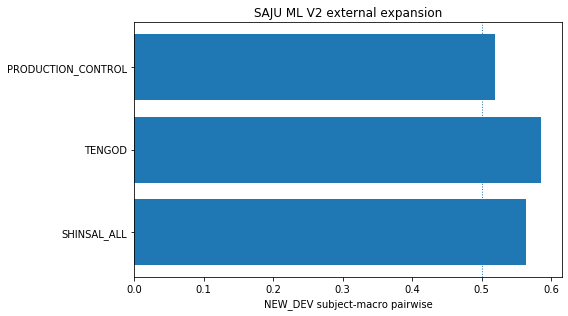

In [16]:
plot_df = pd.concat([
    pd.DataFrame([{
        "candidate": "PRODUCTION_CONTROL",
        "macro_pairwise": control_metrics["macro_pairwise"],
    }]),
    dev_results[["candidate", "macro_pairwise"]],
], ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(plot_df["candidate"], plot_df["macro_pairwise"])
ax.axvline(0.5, linestyle=":", linewidth=1)
ax.set_xlabel("NEW_DEV subject-macro pairwise")
ax.set_title("SAJU ML V2 external expansion")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# STOP HERE ON THE FIRST RUN

With `RUN_CONFIRM=False`, the notebook **must not read** the sealed confirmation file.

Review:

- `V2_DEV_candidate_results.csv`
- `V2_DEV_WINNER_FREEZE.json`

Only if the NEW_DEV freeze is acceptable should you manually change:

```python
RUN_CONFIRM = True
```

and Run All again.

If `status == V2_DEV_NO_CANDIDATE_SURVIVES`, do not open confirmation.

In [17]:
if not RUN_CONFIRM:
    print("NEW_CONFIRM remains sealed.")
    print("Send these back for review:")
    print(" -", V2_ARTIFACT_DIR / "V2_DEV_candidate_results.csv")
    print(" -", WINNER_FREEZE_PATH)
elif winner is None:
    print("RUN_CONFIRM=True but no winner survived. Confirmation will NOT run.")
else:
    print("RUN_CONFIRM=True and a frozen winner exists:", winner)

NEW_CONFIRM remains sealed.
Send these back for review:
 - /Users/sangjinlee/Desktop/projects/saju/research/ml/artifacts/v2/V2_DEV_candidate_results.csv
 - /Users/sangjinlee/Desktop/projects/saju/research/ml/artifacts/v2/V2_DEV_WINNER_FREEZE.json


# 10. One-shot NEW_CONFIRM

This section is inert unless `RUN_CONFIRM=True` **and** a winner exists.

The winner is refit on V1 + NEW_DEV using the same fixed architecture and feature schema, then scored once on 30 fresh subjects.

In [18]:
if RUN_CONFIRM and winner is not None:
    if not V2_CONFIRM_PATH.exists():
        raise FileNotFoundError(V2_CONFIRM_PATH)

    confirm_corpus = load_json(V2_CONFIRM_PATH)
    assert (
        confirm_corpus["corpus_version"]
        == "SAJU_ML_CORPUS_V2_NEW_CONFIRM_SEALED"
    )
    assert len(confirm_corpus["subjects"]) == 30

    confirm_names = {s["name"] for s in confirm_corpus["subjects"]}
    assert not (confirm_names & v1_names)
    assert not (confirm_names & v2_dev_names)

    validate_runtime_birth_range(confirm_corpus, "NEW_CONFIRM")

    confirm_targets, confirm_collisions = build_target_rows(
        confirm_corpus
    )
    assert confirm_targets["subject_id"].nunique() == 30
    assert len(confirm_collisions) == 0

    CONFIRM_FEATURE_CACHE = (
        V2_ARTIFACT_DIR
        / "V2_NEW_CONFIRM_feature_table_R2.csv"
    )

    confirm_features = build_feature_table(
        confirm_corpus,
        confirm_targets,
        CONFIRM_FEATURE_CACHE,
    )

    confirm_df = confirm_targets.merge(
        confirm_features,
        on=["subject_id", "year"],
        how="inner",
        validate="one_to_one",
    )

    winner_cols = CANDIDATES[winner]

    # Refit fixed winner on V1 + all NEW_DEV.
    train_v1 = v1_model_df[
        ["subject_id", "year", "label"] + winner_cols
    ].copy()

    train_dev = dev_model_df[
        ["subject_id", "year", "label"] + winner_cols
    ].copy()

    expanded_train = pd.concat(
        [train_v1, train_dev],
        ignore_index=True,
    )

    final_model = fit_pairwise_model(
        expanded_train, winner_cols
    )

    confirm_pred = confirm_df[
        [
            "subject_id", "name", "origin_group",
            "year", "label", "baseline__control_score"
        ]
    ].copy()

    confirm_pred["score"] = score_rows(
        final_model, confirm_df, winner_cols
    )

    confirm_subject = subject_pairwise_rows(
        confirm_pred, "score"
    )
    confirm_control_subject = subject_pairwise_rows(
        confirm_pred, "baseline__control_score"
    )

    confirm_metrics = aggregate(confirm_subject)
    confirm_control_metrics = aggregate(
        confirm_control_subject
    )

    confirm_boot, confirm_paired = paired_bootstrap(
        confirm_subject,
        confirm_control_subject,
    )

    confirm_result = {
        "winner": winner,
        "n_features": len(winner_cols),
        "n_subjects": confirm_metrics["n_subjects"],
        "macro_pairwise": confirm_metrics["macro_pairwise"],
        "subject_hit_rate": confirm_metrics["subject_hit_rate"],
        "control_pairwise": confirm_control_metrics["macro_pairwise"],
        "control_hit_rate": confirm_control_metrics["subject_hit_rate"],
        "delta_vs_control": (
            confirm_metrics["macro_pairwise"]
            - confirm_control_metrics["macro_pairwise"]
        ),
        **{
            f"bootstrap_{k}": v
            for k, v in confirm_boot.items()
        },
    }

    confirm_gate = bool(
        confirm_result["macro_pairwise"] >= 0.55
        and confirm_result["delta_vs_control"] >= 0.03
        and confirm_result["bootstrap_p_delta_gt_0"] >= 0.90
        and (
            confirm_result["subject_hit_rate"]
            >= confirm_result["control_hit_rate"]
        )
    )

    final_status = (
        "V2_CONFIRM_SUPPORTS_GENERALIZATION"
        if confirm_gate
        else "V2_CONFIRM_FAIL"
    )

    pd.DataFrame([confirm_result]).to_csv(
        V2_ARTIFACT_DIR / "V2_CONFIRM_one_shot_results.csv",
        index=False,
    )
    confirm_paired.to_csv(
        V2_ARTIFACT_DIR / "V2_CONFIRM_subject_deltas.csv",
        index=False,
    )

    final_decision = {
        "version": "SAJU_ML_V2_CONFIRM_FINAL_DECISION",
        "created_at": datetime.now().isoformat(timespec="seconds"),
        "status": final_status,
        "winner": winner,
        "refit_policy": freeze_payload["confirmation_refit_policy"],
        "confirm_result": confirm_result,
        "integrity": {
            "winner_freeze_sha256": sha256_file(
                WINNER_FREEZE_PATH
            ),
            "V2_CONFIRM_sha256": sha256_file(
                V2_CONFIRM_PATH
            ),
            "candidate_freeze_sha256": sha256_file(
                CANDIDATE_FREEZE_PATH
            ),
        },
        "next_rule": (
            "Do not open Public CHECK/FINAL from this notebook. "
            "Report V2 confirmation before any further model decision."
        ),
    }

    json.dump(
        final_decision,
        open(
            V2_ARTIFACT_DIR / "V2_CONFIRM_final_decision.json",
            "w",
            encoding="utf-8",
        ),
        ensure_ascii=False,
        indent=2,
    )

    print("ONE-SHOT STATUS:", final_status)
    display(pd.DataFrame([confirm_result]))

else:
    print("Confirmation section skipped.")

Confirmation section skipped.


## 11. What to send back

### First run, `RUN_CONFIRM=False`

Send:

```text
research/ml/artifacts/v2/
├── V2_DEV_candidate_results.csv
└── V2_DEV_WINNER_FREEZE.json
```

Do **not** manually inspect or tune against `NEW_CONFIRM`.

### Only after the NEW_DEV freeze is reviewed

Set `RUN_CONFIRM=True`, Run All, then send:

```text
research/ml/artifacts/v2/
├── V2_CONFIRM_one_shot_results.csv
├── V2_CONFIRM_subject_deltas.csv
└── V2_CONFIRM_final_decision.json
```

R2 engine-range QA is enforced before both NEW_DEV and NEW_CONFIRM feature extraction.